## Genomics

Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable. 

2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes. 

3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values. 

5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

7. Why do regularization methods lend themselves to scenarios like precision health? 

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LassoCV
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
import warnings 
warnings.filterwarnings("ignore")

In [3]:
# 1.
df = pd.read_csv('data/golub.csv')
df.head()

df['cancer'] = df['cancer'].replace({'allB': 0, 'allT': 0, 'aml': 1}).infer_objects(copy=False)


Mean Squared Error: 1.2591729976403748e-30


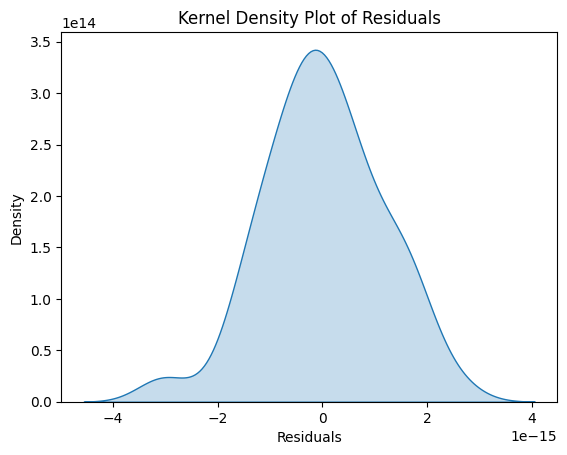

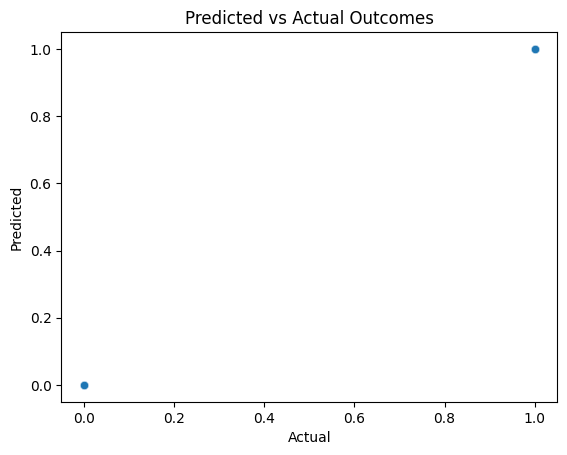

In [4]:
# 2. 
# Features: all gene columns excluding Samples
X = df.select_dtypes(include=[np.number]).drop('Samples', axis=1)
# Scale features for LASSO
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Target: cancer
y = df['cancer']

model = LinearRegression()
model.fit(X_scaled, y)

y_pred = model.predict(X_scaled)

mse = mean_squared_error(y, y_pred)
print(f'Mean Squared Error: {mse}')

residuals = y - y_pred

sns.kdeplot(residuals, fill=True)
plt.title('Kernel Density Plot of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Density')
plt.show()

# Scatter Plot: Predicted vs Actual
sns.scatterplot(x=y, y=y_pred, alpha=0.6)
#plt.plot([y.min(), y.max()], [y.min(), y.max()], 'b--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Predicted vs Actual Outcomes')
plt.show()

In [5]:
#3
cv = KFold(n_splits=5, shuffle=True)

cv_scores = cross_val_score(LinearRegression(), X, y, cv=cv, scoring='neg_mean_squared_error', n_jobs=1)

cv_mse = -cv_scores
print("CV MSE per fold:", np.round(cv_mse, 4))
print("CV MSE mean:", np.round(cv_mse.mean(), 4))
print("CV MSE std :", np.round(cv_mse.std(), 4))

print("Interpretation of bias-variance trade-off: \nTraining MSE close to 0, which means low bias on training data, and the CV MSE is higher, " \
"showing variance/overfitting. Should regularize or feature select.")

CV MSE per fold: [0.0251 0.0244 0.0522 0.051  0.0497]
CV MSE mean: 0.0405
CV MSE std : 0.0129
Interpretation of bias-variance trade-off: 
Training MSE close to 0, which means low bias on training data, and the CV MSE is higher, showing variance/overfitting. Should regularize or feature select.


Best alpha: 105.24436668425457
Selected genes (34): ['HG3549-HT3751_at', 'J04164_at', 'L38941_at', 'M11147_at', 'M11722_at', 'M17733_at', 'M19507_at', 'M26602_at', 'M27891_at', 'M33680_at', 'M63138_at', 'M77232_rna1_at', 'M91036_rna1_at', 'M96326_rna1_at', 'U14968_at', 'X04500_at', 'X17042_at', 'X78992_at', 'Z70759_at', 'L06797_s_at', 'D49824_s_at', 'M25079_s_at', 'X57351_s_at', 'V00594_s_at', 'U05255_s_at', 'X03689_s_at', 'M14328_s_at', 'M14483_rna1_s_at', 'M26708_s_at', 'Y00787_s_at', 'Z19554_s_at', 'X56681_s_at', 'HG2887-HT3031_at', 'M33600_f_at']
Genes discarded: 7096
LASSO MSE: 0.008593030296989622


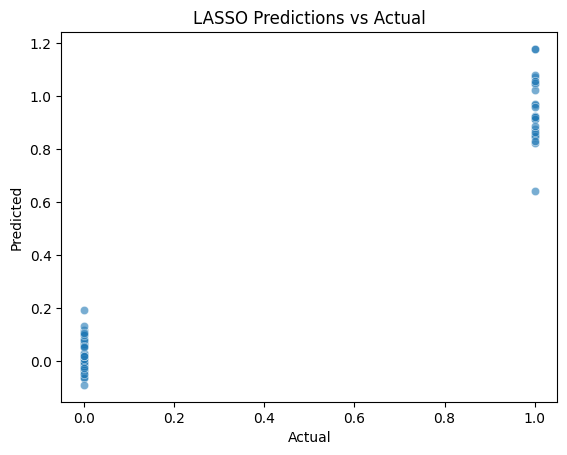

In [6]:
#4

lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X, y)

print(f'Best alpha: {lasso.alpha_}')

# Selected genes
selected_genes = X.columns[lasso.coef_ != 0]
print(f'Selected genes ({len(selected_genes)}): {list(selected_genes)}')

# Discarded genes
discarded_count = len(X.columns) - len(selected_genes)
print(f'Genes discarded: {discarded_count}')

y_pred_lasso = lasso.predict(X)

mse_lasso = mean_squared_error(y, y_pred_lasso)
print(f'LASSO MSE: {mse_lasso}')

sns.scatterplot(x=y, y=y_pred_lasso, alpha=0.6)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('LASSO Predictions vs Actual')
plt.show()

Optimal alpha: 105.2444
Minimum CV MSE: 0.0628
Overfitting when  : alpha << 105.2444


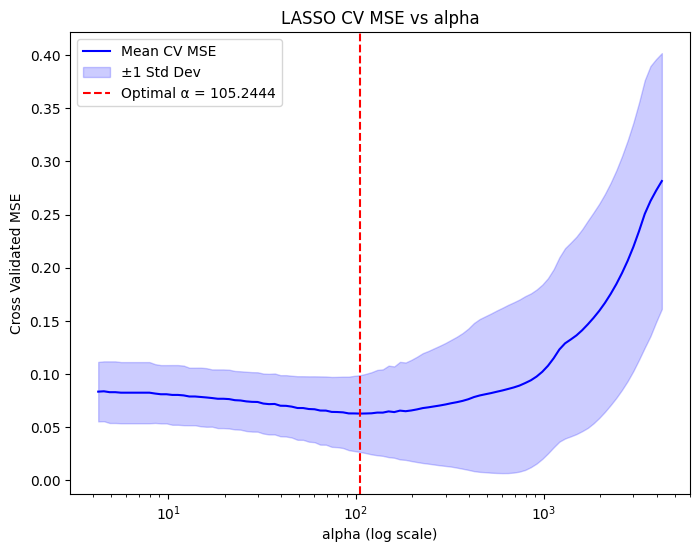

In [7]:
# 5

mean_mse_path = np.mean(lasso.mse_path_, axis=1)
std_mse_path = np.std(lasso.mse_path_, axis=1)

optimal_idx = np.argmin(mean_mse_path)
optimal_mse = mean_mse_path[optimal_idx]
optimal_alpha = lasso.alphas_[optimal_idx]

print(f'Optimal alpha: {optimal_alpha:.4f}')
print(f'Minimum CV MSE: {optimal_mse:.4f}')
print(f"Overfitting when  : alpha << {optimal_alpha:.4f}")

fig, ax = plt.subplots(figsize=(8, 6))
ax.semilogx(lasso.alphas_, mean_mse_path, 'b-', label='Mean CV MSE')
ax.fill_between(lasso.alphas_, mean_mse_path - std_mse_path, mean_mse_path + std_mse_path, color='blue', alpha=0.2, label='±1 Std Dev')
ax.axvline(optimal_alpha, color='r', linestyle='--', label=f'Optimal α = {optimal_alpha:.4f}')
ax.set_xlabel('alpha (log scale)')
ax.set_ylabel('Cross Validated MSE')
ax.set_title('LASSO CV MSE vs alpha')
ax.legend()
plt.show()



In [8]:
# 6
print("""end=
      Linear regression is beaten by LASSO in prediction accuracy because it performs feature selection, reducing overfitting and improving generalization to unseen data.
      OLS includes all features and sampling noise and gives train MSE close to 0 but higher CV MSE, while LASSO selects a subset of features, reducing variance and improving CV MSE. To avoid extreme overfitting,
      LASSO introduces bias by shrinking coefficients, but this bias can lead to lower overall MSE on new data compared to OLS, which has low bias but high variance. The optimal alpha balances this bias-variance trade-off.""")

end=
      Linear regression is beaten by LASSO in prediction accuracy because it performs feature selection, reducing overfitting and improving generalization to unseen data.
      OLS includes all features and sampling noise and gives train MSE close to 0 but higher CV MSE, while LASSO selects a subset of features, reducing variance and improving CV MSE. To avoid extreme overfitting,
      LASSO introduces bias by shrinking coefficients, but this bias can lead to lower overall MSE on new data compared to OLS, which has low bias but high variance. The optimal alpha balances this bias-variance trade-off.


In [10]:
# 7.
print("""end=
      Regularization methods are used in scenarios like precsion health because 
      precision health often involves high-dimensional data (eg genomics) where the number of features is larger than the number of samples. Regularization helps prevent overfitting by adding a penalty to the model complexity, allowing for better generalization to unseen data. In precision health, this can lead to more accurate predictions of disease risk, treatment response, and patient outcomes, ultimately improving personalized medicine approaches.""")

end=
      Regularization methods are used in scenarios like precsion health because 
      precision health often involves high-dimensional data (eg genomics) where the number of features is larger than the number of samples. Regularization helps prevent overfitting by adding a penalty to the model complexity, allowing for better generalization to unseen data. In precision health, this can lead to more accurate predictions of disease risk, treatment response, and patient outcomes, ultimately improving personalized medicine approaches.


In [12]:
# 8.
print("""end=
      The risk of the LASSO method in clinical intervention is that it may exclude important features (genes) that have small but meaningful effects on the outcome, leading to suboptimal treatment decisions. 
      Also, LASSO's performance can be sensitive to the choice of alpha, it is very instable and may either overfit or underfit the data, potentially resulting in inaccurate predictions and ineffective interventions.""")

end=
      The risk of the LASSO method in clinical intervention is that it may exclude important features (genes) that have small but meaningful effects on the outcome, leading to suboptimal treatment decisions. 
      Also, LASSO's performance can be sensitive to the choice of alpha, it is very instable and may either overfit or underfit the data, potentially resulting in inaccurate predictions and ineffective interventions.
